In [8]:
!pip install imbalanced-learn -q

In [9]:
!pip install optuna -q

In [10]:
!pip install koreanize-matplotlib

In [11]:
# 필요 라이브러리 임포트
import os
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

import time
from tqdm import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,             # AUROC
    average_precision_score,   # AUPR
    recall_score,              # Recall
    f1_score,                  # F1
    fbeta_score,               # F-beta
    precision_score,           # Precision (F1 계산 참고용)
    confusion_matrix           # TP/FP/TN/FN 확인용
)

In [12]:
# ================================
# 0) 재현성(reproducibility) 설정
# ================================
def set_seed(seed: int = 11) -> None:
    """실험 결과를 최대한 재현 가능하게 만들기 위한 시드 고정 함수"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # GPU 사용 시 GPU용 난수 시드도 함께 고정
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

In [13]:
# ===================================================
# 하이퍼파라미터 (Supplementary Table S3. MOLI_Complete_Pan_Drug)
# ===================================================

# Encoder
HIDDEN_DIM_EXPR = 32
HIDDEN_DIM_MUT  = 16
HIDDEN_DIM_CNA  = 256

# Drug Embedding
DRUG_TO_IDX = {
    'Cetuximab' : 0,
    'Afatinib'  : 1,
    'Erlotinib' : 2,
    'Gefitinib' : 3,
    'Lapatinib' : 4
}
IDX_TO_DRUG  = {v: k for k, v in DRUG_TO_IDX.items()}
NUM_DRUGS    = len(DRUG_TO_IDX)   # 5
DRUG_EMB_DIM = 8                  # 약물 임베딩 차원

# Classifier
Z_IN            = HIDDEN_DIM_EXPR + HIDDEN_DIM_MUT + HIDDEN_DIM_CNA  # 304
Z_TOTAL = Z_IN + DRUG_EMB_DIM     # 304 + 8 = 312

# Learning Rate
LR_EXPR = 0.001
LR_MUT  = 0.0001
LR_CNA  = 5e-5
LR_CLS  = 0.005

# Dropout
DROPOUT_EXPR = 0.5
DROPOUT_MUT  = 0.8
DROPOUT_CNA  = 0.5
DROPOUT_CLS  = 0.3

# 학습 설정
WEIGHT_DECAY = 0.0001
BATCH_SIZE   = 16
GAMMA        = 0.5
MARGIN       = 1.5
EPOCHS       = 20
FOLDS        = 5   # Cross Validation 구현 시 사용


print("📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)")
print(f"  Encoder hidden : expr={HIDDEN_DIM_EXPR} / mut={HIDDEN_DIM_MUT} / cna={HIDDEN_DIM_CNA}")
print(f"  Z_IN           : {Z_IN}  (encoder concat)")
print(f"  Drug Embedding : {NUM_DRUGS}약물 × {DRUG_EMB_DIM}차원")
print(f"  Z_TOTAL        : {Z_TOTAL}  (Z_IN + drug_emb)")
print(f"  LR             : expr={LR_EXPR} / mut={LR_MUT} / cna={LR_CNA} / cls={LR_CLS}")
print(f"  Dropout        : expr={DROPOUT_EXPR} / mut={DROPOUT_MUT} / cna={DROPOUT_CNA} / cls={DROPOUT_CLS}")
print(f"  weight_decay   : {WEIGHT_DECAY} (classifier only)")
print(f"  batch={BATCH_SIZE} / gamma={GAMMA} / margin={MARGIN} / epochs={EPOCHS}")

📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)
  Encoder hidden : expr=32 / mut=16 / cna=256
  Z_IN           : 304  (encoder concat)
  Drug Embedding : 5약물 × 8차원
  Z_TOTAL        : 312  (Z_IN + drug_emb)
  LR             : expr=0.001 / mut=0.0001 / cna=5e-05 / cls=0.005
  Dropout        : expr=0.5 / mut=0.8 / cna=0.5 / cls=0.3
  weight_decay   : 0.0001 (classifier only)
  batch=16 / gamma=0.5 / margin=1.5 / epochs=20


In [14]:
# ===================================================
# 1) 데이터 로드
# ===================================================

BASE_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI"
save_dir = os.path.join(BASE_DIR, "preprocessed_EGFRi")

# Train
X_train_expr = np.load(f"{save_dir}/X_train_expr.npy")
X_train_mut  = np.load(f"{save_dir}/X_train_mut.npy")
X_train_cna  = np.load(f"{save_dir}/X_train_cna.npy")
drug_id_train = np.load(f"{save_dir}/drug_id_train.npy")
y_train      = np.load(f"{save_dir}/y_train.npy")

# Val (PDX)
X_val_expr   = np.load(f"{save_dir}/X_val_expr.npy")
X_val_mut    = np.load(f"{save_dir}/X_val_mut.npy")
X_val_cna    = np.load(f"{save_dir}/X_val_cna.npy")
drug_id_val  = np.load(f"{save_dir}/drug_id_val.npy")
y_val        = np.load(f"{save_dir}/y_val.npy")

# Val (TCGA)
X_tcga_expr  = np.load(f"{save_dir}/X_tcga_expr.npy")
X_tcga_mut   = np.load(f"{save_dir}/X_tcga_mut.npy")
X_tcga_cna   = np.load(f"{save_dir}/X_tcga_cna.npy")
drug_id_tcga = np.load(f"{save_dir}/drug_id_tcga.npy")
y_tcga       = np.load(f"{save_dir}/y_tcga.npy")

# 입력 차원
INPUT_DIM_EXPR = X_train_expr.shape[1]  # 18232
INPUT_DIM_MUT  = X_train_mut.shape[1]   # 14447
INPUT_DIM_CNA  = X_train_cna.shape[1]   # 20503

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ 데이터 로드 완료")
print(f"  Train: {X_train_expr.shape[0]}샘플 | R:{int((y_train==0).sum())} S:{int((y_train==1).sum())}")
print(f"  PDX  : {X_val_expr.shape[0]}샘플   | R:{int((y_val==0).sum())} S:{int((y_val==1).sum())}")
print(f"  TCGA : {X_tcga_expr.shape[0]}샘플   | R:{int((y_tcga==0).sum())} S:{int((y_tcga==1).sum())}")
print(f"\n📐 입력 차원:")
print(f"  Expression : {INPUT_DIM_EXPR:,}")
print(f"  Mutation   : {INPUT_DIM_MUT:,}")
print(f"  CNA        : {INPUT_DIM_CNA:,}")
print(f"\n💊 Drug ID 확인:")
print(f"  Train drug_id : {drug_id_train.shape} dtype={drug_id_train.dtype}")
print(f"  Val   drug_id : {drug_id_val.shape}   dtype={drug_id_val.dtype}")
print(f"  TCGA  drug_id : {drug_id_tcga.shape}  dtype={drug_id_tcga.dtype}")
print(f"  매핑: {IDX_TO_DRUG}")
print(f"\n🖥️  장치: {device}")

✅ 데이터 로드 완료
  Train: 3258샘플 | R:2747 S:511
  PDX  : 81샘플   | R:73 S:8
  TCGA : 15샘플   | R:8 S:7

📐 입력 차원:
  Expression : 18,232
  Mutation   : 14,447
  CNA        : 20,503

💊 Drug ID 확인:
  Train drug_id : (3258,) dtype=int64
  Val   drug_id : (81,)   dtype=int64
  TCGA  drug_id : (15,)  dtype=int64
  매핑: {0: 'Cetuximab', 1: 'Afatinib', 2: 'Erlotinib', 3: 'Gefitinib', 4: 'Lapatinib'}

🖥️  장치: cuda


In [15]:
# 오믹스 데이터셋 클래스 생성
class OmicsDataset(Dataset):
    """
    3가지 Omics 데이터를 하나의 Dataset으로 묶는 클래스
    논문 Figure 1 입력 구조 구현
    """
    def __init__(self, expr, mut, cna, drug_ids, labels):
        self.expr     = torch.FloatTensor(expr)
        self.mut      = torch.FloatTensor(mut)
        self.cna      = torch.FloatTensor(cna)
        self.drug_ids = torch.LongTensor(drug_ids)
        self.labels   = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.expr[idx],
            self.mut[idx],
            self.cna[idx],
            self.drug_ids[idx],
            self.labels[idx]
        )

In [16]:
# SMOTE
n_expr = X_train_expr.shape[1]
n_mut  = X_train_mut.shape[1]
n_cna  = X_train_cna.shape[1]

X_concat = np.hstack([X_train_expr, X_train_mut, X_train_cna])

all_X_sm       = []
all_y_sm       = []
all_drug_id_sm = []

print("약물별 SMOTE 적용:")
print(f"{'약물':12s} {'원본 R':>8s} {'원본 S':>8s} {'합성 S':>8s} {'최종':>8s}")
print("-" * 50)

for drug_name, drug_idx in DRUG_TO_IDX.items():
    mask = (drug_id_train == drug_idx)
    X_d  = X_concat[mask]
    y_d  = y_train[mask]

    n_r = int((y_d == 0).sum())
    n_s = int((y_d == 1).sum())

    if n_s < 2:
        # S 샘플이 1개 이하 → SMOTE 불가, 그대로 사용
        all_X_sm.append(X_d)
        all_y_sm.append(y_d)
        all_drug_id_sm.append(np.full(len(y_d), drug_idx, dtype=np.int64))
        print(f"{drug_name:12s} {n_r:8d} {n_s:8d} {'불가':>8s} {len(y_d):8d}")
        continue

    # k_neighbors: S 샘플 수 - 1 이하로 제한
    k = min(5, n_s - 1)

    smote = SMOTE(
        sampling_strategy = 0.3,
        k_neighbors       = k,
        random_state      = 42
    )

    try:
        X_resampled, y_resampled = smote.fit_resample(X_d, y_d)
        n_synthetic = int((y_resampled == 1).sum()) - n_s

        all_X_sm.append(X_resampled)
        all_y_sm.append(y_resampled)
        all_drug_id_sm.append(
            np.full(len(y_resampled), drug_idx, dtype=np.int64)
        )
        print(f"{drug_name:12s} {n_r:8d} {n_s:8d} {n_synthetic:8d} {len(y_resampled):8d}")

    except Exception as e:
        # SMOTE 실패 시 원본 그대로
        all_X_sm.append(X_d)
        all_y_sm.append(y_d)
        all_drug_id_sm.append(np.full(len(y_d), drug_idx, dtype=np.int64))
        print(f"{drug_name:12s} {n_r:8d} {n_s:8d} {'오류':>8s} {len(y_d):8d} ({e})")

# 합치기
X_all_sm       = np.vstack(all_X_sm)
y_train_sm     = np.concatenate(all_y_sm).astype(np.float32)
drug_id_train_sm = np.concatenate(all_drug_id_sm).astype(np.int64)

# omics 분리
X_train_expr_sm = X_all_sm[:, :n_expr].astype(np.float32)
X_train_mut_sm  = X_all_sm[:, n_expr:n_expr+n_mut].astype(np.float32)
X_train_cna_sm  = X_all_sm[:, n_expr+n_mut:].astype(np.float32)

# Mutation/CNA 이진화 (SMOTE 후 소수점 생길 수 있음)
X_train_mut_sm = (X_train_mut_sm >= 0.5).astype(np.float32)
X_train_cna_sm = np.clip(np.round(X_train_cna_sm), -1, 1).astype(np.float32)

print("-" * 50)
print(f"\n✅ SMOTE 완료")
print(f"  원본: {len(y_train):,}샘플 "
      f"(R:{int((y_train==0).sum())} S:{int((y_train==1).sum())})")
print(f"  이후: {len(y_train_sm):,}샘플 "
      f"(R:{int((y_train_sm==0).sum())} S:{int((y_train_sm==1).sum())})")

# 약물별 최종 분포 확인
print(f"\n  약물별 최종 분포:")
for drug_name, drug_idx in DRUG_TO_IDX.items():
    m  = (drug_id_train_sm == drug_idx)
    nr = int((y_train_sm[m] == 0).sum())
    ns = int((y_train_sm[m] == 1).sum())
    print(f"    {drug_name:12s}: R={nr} S={ns}")

# 데이터 정렬 검증
print(f"\n  정렬 검증:")
for drug_name, drug_idx in DRUG_TO_IDX.items():
    m = (drug_id_train_sm == drug_idx)
    assert all(drug_id_train_sm[m] == drug_idx), f"{drug_name} drug_id 불일치!"
print(f"  ✅ 모든 약물 drug_id 정렬 정상")

약물별 SMOTE 적용:
약물               원본 R     원본 S     합성 S       최종
--------------------------------------------------
Cetuximab         735      121       99      955
Afatinib          678      150       53      881
Erlotinib         298       64       25      387
Gefitinib         710      115       98      923
Lapatinib         326       61       36      423
--------------------------------------------------

✅ SMOTE 완료
  원본: 3,258샘플 (R:2747 S:511)
  이후: 3,569샘플 (R:2747 S:822)

  약물별 최종 분포:
    Cetuximab   : R=735 S=220
    Afatinib    : R=678 S=203
    Erlotinib   : R=298 S=89
    Gefitinib   : R=710 S=213
    Lapatinib   : R=326 S=97

  정렬 검증:
  ✅ 모든 약물 drug_id 정렬 정상


In [17]:
# ===================================================
# 2) Dataset + DataLoader
# ===================================================

# SMOTE 적용 DataLoader 생성
train_dataset_sm = OmicsDataset(
    X_train_expr_sm, X_train_mut_sm,
    X_train_cna_sm,  drug_id_train_sm,
    y_train_sm
)

# SMOTE 후 클래스 균형이 맞춰졌으므로 WeightedSampler 없이 shuffle만 사용
train_loader_sm = DataLoader(
    train_dataset_sm,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    drop_last  = True
)

# 분포 확인
print(f"SMOTE DataLoader:")
print(f"  {len(train_dataset_sm)}샘플 / {len(train_loader_sm)}배치")
print(f"  R:{int((y_train_sm==0).sum())} S:{int((y_train_sm==1).sum())} "
      f"비율={int((y_train_sm==0).sum())/int((y_train_sm==1).sum()):.2f}:1")

SMOTE DataLoader:
  3569샘플 / 223배치
  R:2747 S:822 비율=3.34:1


In [18]:
# Dataset 생성
val_dataset   = OmicsDataset(X_val_expr,   X_val_mut,   X_val_cna,   drug_id_val,   y_val)
tcga_dataset  = OmicsDataset(X_tcga_expr,  X_tcga_mut,  X_tcga_cna,  drug_id_tcga,  y_tcga)

# DataLoader
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False)
tcga_loader = DataLoader(tcga_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
# ===================================================
# 3) 모델 정의
# ===================================================

# 3-1) Encoder
class OmicsEncoder(nn.Module):
    """Linear → BatchNorm → ReLU → Dropout"""
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.encoder(x)


# 3-2) Classifier
class Classifier(nn.Module):
    """Linear → Dropout → Sigmoid"""
    def __init__(self, z_total, dropout):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_total, 1),
            nn.Dropout(dropout),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.fc(x).squeeze(1)   # (N,1) → (N,)


# 3-3) MOLI + Drug Embedding
class MOLI(nn.Module):
    """
    Expression  → Encoder_E ──┐
    Mutation    → Encoder_M ──┼→ Concat(304) ──┐
    CNA         → Encoder_C ──┘                ├→ L2 Norm → Classifier → R/S
    Drug ID     → Embedding(8) ────────────────┘
    """
    def __init__(self, input_dim_expr, input_dim_mut, input_dim_cna,
                 hidden_dim_expr=HIDDEN_DIM_EXPR,
                 hidden_dim_mut=HIDDEN_DIM_MUT,
                 hidden_dim_cna=HIDDEN_DIM_CNA,
                 drug_emb_dim=DRUG_EMB_DIM,
                 dropout_expr=DROPOUT_EXPR,
                 dropout_mut=DROPOUT_MUT,
                 dropout_cna=DROPOUT_CNA,
                 dropout_cls=DROPOUT_CLS):
        super().__init__()

        # z_total을 인자로 받지 않고 내부에서 계산
        z_total = hidden_dim_expr + hidden_dim_mut + hidden_dim_cna + drug_emb_dim

        self.expr_encoder   = OmicsEncoder(input_dim_expr, hidden_dim_expr, dropout_expr)
        self.mut_encoder    = OmicsEncoder(input_dim_mut,  hidden_dim_mut,  dropout_mut)
        self.cna_encoder    = OmicsEncoder(input_dim_cna,  hidden_dim_cna,  dropout_cna)
        self.drug_embedding = nn.Embedding(NUM_DRUGS, drug_emb_dim)
        self.classifier     = Classifier(z_total, dropout_cls)

    def encode(self, expr, mut, cna, drug_id):
        z_expr = self.expr_encoder(expr)
        z_mut  = self.mut_encoder(mut)
        z_cna  = self.cna_encoder(cna)
        z_drug = self.drug_embedding(drug_id)
        z = torch.cat([z_expr, z_mut, z_cna, z_drug], dim=1)
        z = F.normalize(z, p=2, dim=1)
        return z

    def forward(self, expr, mut, cna, drug_id):
        return self.classifier(self.encode(expr, mut, cna, drug_id))

    def forward_train(self, expr, mut, cna, drug_id):
        z = self.encode(expr, mut, cna, drug_id)
        return self.classifier(z), z


# 3-4) 모델 생성
model = MOLI(
    input_dim_expr = INPUT_DIM_EXPR,
    input_dim_mut  = INPUT_DIM_MUT,
    input_dim_cna  = INPUT_DIM_CNA
).to(device)

# 3-5) Optimizer (원본: Encoder weight_decay 없음, Classifier만 있음)
solverE   = optim.Adagrad(model.expr_encoder.parameters(), lr=LR_EXPR)
solverM   = optim.Adagrad(model.mut_encoder.parameters(), lr=LR_MUT)
solverC   = optim.Adagrad(model.cna_encoder.parameters(), lr=LR_CNA)
solverCLS = optim.Adagrad(model.classifier.parameters(), lr=LR_CLS, weight_decay=WEIGHT_DECAY)
# Drug Embedding은 Classifier optimizer에 포함
solverDRUG = optim.Adagrad(model.drug_embedding.parameters(), lr=LR_CLS)

# 3-6) 확인
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ 모델 생성 완료")
print(f"  구조: omics → FC(32/16/256) → concat(304)")
print(f"        drug  → Embedding(5×8=40 params)")
print(f"        total concat: {Z_TOTAL} → classifier")
print(f"  전체 파라미터: {total_params:,}")

expr_b, mut_b, cna_b, drug_b, label_b = next(iter(train_loader_sm))
with torch.no_grad():
    z   = model.encode(
        expr_b.to(device), mut_b.to(device),
        cna_b.to(device),  drug_b.to(device)
    )
    out = model(
        expr_b.to(device), mut_b.to(device),
        cna_b.to(device),  drug_b.to(device)
    )
print(f"\nshape 확인:")
print(f"  encode 출력 z : {tuple(z.shape)}  ← (N, {Z_TOTAL})")
print(f"  forward 출력  : {tuple(out.shape)} ← (N,)")
print(f"  범위: [{out.min():.3f}, {out.max():.3f}]  ← (0, 1) 정상")

✅ 모델 생성 완료
  구조: omics → FC(32/16/256) → concat(304)
        drug  → Embedding(5×8=40 params)
        total concat: 312 → classifier
  전체 파라미터: 6,064,609

shape 확인:
  encode 출력 z : (16, 312)  ← (N, 312)
  forward 출력  : (16,) ← (N,)
  범위: [0.461, 0.511]  ← (0, 1) 정상


In [20]:
# ===================================================
# 4) 손실 함수 정의
# ===================================================
# PyTorch 내장 TripletMarginLoss 사용

trip_criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
bce_loss       = nn.BCELoss()

print("✅ Loss 함수 준비 완료")
print(f"  TripletMarginLoss : margin={MARGIN}, p=2 (원본과 동일)")
print(f"  BCELoss           : ✅")
print(f"  γ (gamma)         : {GAMMA}")

✅ Loss 함수 준비 완료
  TripletMarginLoss : margin=1.5, p=2 (원본과 동일)
  BCELoss           : ✅
  γ (gamma)         : 0.5


In [21]:
# ===================================================
# 5) AllTripletSelector
# ===================================================
def get_all_triplets(embeddings, labels):
    """
    원본 AllTripletSelector 완전 구현
    (A=S, P=S, N=R) + (A=R, P=R, N=S) 모든 조합
    """
    s_idx = torch.where(labels == 1)[0]
    r_idx = torch.where(labels == 0)[0]

    if len(s_idx) < 2 or len(r_idx) < 2:
        return None

    triplets = []

    # 방향 1: Anchor=S, Positive=S, Negative=R
    for i in range(len(s_idx)):
        for j in range(len(s_idx)):
            if i == j:
                continue
            for k in range(len(r_idx)):
                triplets.append([s_idx[i], s_idx[j], r_idx[k]])

    # 방향 2: Anchor=R, Positive=R, Negative=S
    for i in range(len(r_idx)):
        for j in range(len(r_idx)):
            if i == j:
                continue
            for k in range(len(s_idx)):
                triplets.append([r_idx[i], r_idx[j], s_idx[k]])

    return torch.tensor(triplets, device=embeddings.device)


# reduction='sum': Easy Triplet 희석 방지
trip_criterion = nn.TripletMarginLoss(
    margin    = MARGIN,
    p         = 2,
    reduction = 'sum'    # 원인 4 수정
)
bce_loss = nn.BCELoss()

# 동작 확인
dummy_emb    = torch.randn(8, Z_TOTAL)
dummy_labels = torch.tensor([1,0,1,0,1,0,1,0], dtype=torch.float32)
dummy_trips  = get_all_triplets(dummy_emb, dummy_labels)

s_count = (dummy_labels == 1).sum().item()
r_count = (dummy_labels == 0).sum().item()
expected = s_count*(s_count-1)*r_count + r_count*(r_count-1)*s_count

print(f"✅ AllTripletSelector 완전 구현")
print(f"  (A=S,P=S,N=R): {s_count}×{s_count-1}×{r_count} = {s_count*(s_count-1)*r_count}개")
print(f"  (A=R,P=R,N=S): {r_count}×{r_count-1}×{s_count} = {r_count*(r_count-1)*s_count}개")
print(f"  총 triplet   : {len(dummy_trips)}개  (기대: {expected}개) "
      + ("✅" if len(dummy_trips) == expected else "❌"))
print(f"\n  TripletMarginLoss reduction='sum' ✅")

✅ AllTripletSelector 완전 구현
  (A=S,P=S,N=R): 4×3×4 = 48개
  (A=R,P=R,N=S): 4×3×4 = 48개
  총 triplet   : 96개  (기대: 96개) ✅

  TripletMarginLoss reduction='sum' ✅


In [22]:
# ===================================================
# 5-b) Hard Triplets
# ===================================================
def get_hard_triplets(embeddings, labels):
    """
    Hard Triplet Mining:
    - Hardest Positive: Anchor와 가장 먼 같은 클래스
    - Hardest Negative: Anchor와 가장 가까운 다른 클래스
    → 학습에 실제로 유효한 triplet만 선택
    → triplet 수 = 샘플 수 (폭발 없음)
    → gradient 희석 문제 자동 해결
    """
    s_idx = torch.where(labels == 1)[0]
    r_idx = torch.where(labels == 0)[0]

    if len(s_idx) < 2 or len(r_idx) < 1:
        return None

    # 모든 쌍의 거리 계산
    dist = torch.cdist(embeddings, embeddings, p=2)  # (N, N)

    triplets = []

    # S 샘플 각각에 대해 Hard triplet
    for i in s_idx:
        # Hardest Positive: S 중 가장 먼 것
        pos_dists = dist[i][s_idx]
        pos_dists[s_idx == i] = -1  # 자기 자신 제외
        hard_pos = s_idx[pos_dists.argmax()]

        # Hardest Negative: R 중 가장 가까운 것
        neg_dists = dist[i][r_idx]
        hard_neg = r_idx[neg_dists.argmin()]

        triplets.append([i, hard_pos, hard_neg])

    # R 샘플 각각에 대해 Hard triplet
    for i in r_idx:
        if len(r_idx) < 2:
            break
        # Hardest Positive: R 중 가장 먼 것
        pos_dists = dist[i][r_idx]
        pos_dists[r_idx == i] = -1
        hard_pos = r_idx[pos_dists.argmax()]

        # Hardest Negative: S 중 가장 가까운 것
        neg_dists = dist[i][s_idx]
        hard_neg = s_idx[neg_dists.argmin()]

        triplets.append([i, hard_pos, hard_neg])

    return torch.stack([torch.stack(t) for t in triplets])


# reduction='mean' 으로 복구 (Hard Triplet이므로 희석 없음)
trip_criterion = nn.TripletMarginLoss(
    margin    = MARGIN,
    p         = 2,
    reduction = 'mean'
)

# 동작 확인
dummy_emb    = torch.randn(8, Z_TOTAL)
dummy_labels = torch.tensor([1,0,1,0,1,0,1,0], dtype=torch.float32)
dummy_trips  = get_hard_triplets(dummy_emb, dummy_labels)

s_count = (dummy_labels == 1).sum().item()
r_count = (dummy_labels == 0).sum().item()
expected = s_count + r_count  # 샘플 수와 동일

print(f"✅ Hard Triplet Mining 구현")
print(f"  S({s_count}) + R({r_count}) = {len(dummy_trips)}개 "
      + ("✅" if len(dummy_trips) == expected else "❌"))
print(f"  (AllTriplets {s_count*(s_count-1)*r_count*2}개 → {len(dummy_trips)}개로 축소)")
print(f"  reduction='mean' ✅  (희석 문제 해결)")
print(f"\n  AllTriplets vs Hard Triplets:")
print(f"  AllTriplets: 많은 Easy Triplet 포함 → gradient 희석")
print(f"  Hard Triplets: 학습에 유효한 것만 → gradient 집중")

✅ Hard Triplet Mining 구현
  S(4) + R(4) = 8개 ✅
  (AllTriplets 96개 → 8개로 축소)
  reduction='mean' ✅  (희석 문제 해결)

  AllTriplets vs Hard Triplets:
  AllTriplets: 많은 Easy Triplet 포함 → gradient 희석
  Hard Triplets: 학습에 유효한 것만 → gradient 집중


In [23]:
# ===================================================
# 6) 평가 함수
# ===================================================

def evaluate(model, loader, device, dataset_name=""):
    """
    전체 + 약물별 평가 지표 계산
    """
    model.eval()
    all_probs   = []
    all_labels  = []
    all_drug_ids = []

    with torch.no_grad():
        for expr, mut, cna, drug_id, label in loader:
            out = model(
                expr.to(device), mut.to(device),
                cna.to(device),  drug_id.to(device)
            )
            all_probs.extend(out.cpu().numpy())
            all_labels.extend(label.numpy())
            all_drug_ids.extend(drug_id.numpy())

    y_prob  = np.array(all_probs)
    y_true  = np.array(all_labels).astype(int)
    drug_ids = np.array(all_drug_ids)
    y_pred  = (y_prob >= 0.5).astype(int)

    def calc_metrics(y_t, y_p, y_pr, beta=2):
        if len(np.unique(y_t)) < 2:
            return None   # 단일 클래스 → AUROC 계산 불가
        return {
            'AUROC'    : roc_auc_score(y_t, y_pr),
            'AUPR'     : average_precision_score(y_t, y_pr),
            'Recall'   : recall_score(y_t, y_p, zero_division=0),
            'Precision': precision_score(y_t, y_p, zero_division=0),
            'F1'       : f1_score(y_t, y_p, zero_division=0),
            f'F{beta}'  : fbeta_score(y_t, y_p, beta=beta, zero_division=0),
        }

    results = {}

    # 전체 평가
    overall = calc_metrics(y_true, y_pred, y_prob)
    if overall:
        results['overall'] = overall

    # 약물별 평가
    for drug_idx, drug_name in IDX_TO_DRUG.items():
        mask = (drug_ids == drug_idx)
        if mask.sum() == 0:
            continue
        m = calc_metrics(y_true[mask], y_pred[mask], y_prob[mask])
        if m:
            results[drug_name] = m

    # 출력
    if dataset_name:
        print(f"\n{'='*50}")
        print(f"📊 {dataset_name} 평가 결과")
        print(f"{'='*50}")
        for key, m in results.items():
            tag = "전체" if key == 'overall' else f"💊 {key}"
            print(f"  [{tag}]")
            for metric, val in m.items():
                print(f"    {metric:10s}: {val:.4f}")

    return results


print("✅ 평가 함수 준비 완료")
print(f"  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2")
print(f"  평가 방식: 전체 통합 + 약물별 개별")

✅ 평가 함수 준비 완료
  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2
  평가 방식: 전체 통합 + 약물별 개별


In [24]:
# ===================================================
# 7) 학습 루프
# ===================================================

best_pdx_auroc   = 0.0
best_model_state = None
history = {
    'train_loss' : [],
    'train_auroc': [],
    'pdx_auroc'  : [],
    'tcga_auroc' : []
}

print(f"🚀 학습 시작 | epochs={EPOCHS} | batch={BATCH_SIZE} | device={device}")
print("=" * 60)

for epoch in range(EPOCHS):

    # ===================================================
    # 7-1) 한 epoch 학습
    # ===================================================
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    pbar = tqdm(train_loader_sm, desc=f"Epoch {epoch+1:>2}/{EPOCHS} [Train]",
                leave=False, ncols=90)

    for expr, mut, cna, drug_id, target in pbar:

        # 배치 안전 체크: 전부 R 또는 전부 S → Triplet 구성 불가 → skip
        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        # 예측값, 임베딩 얻기
        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        # Triplet Loss
        triplets = get_hard_triplets(embeddings, target)
        if triplets is None:
            continue

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],   # Anchor
            embeddings[triplets[:, 1]],   # Positive
            embeddings[triplets[:, 2]]    # Negative
        )

        # BCE Loss
        bce  = bce_loss(pred, target)

        # Total Loss
        loss = GAMMA * trip_loss + bce

        # 역전파 + 가중치 업데이트
        solverE.zero_grad()
        solverM.zero_grad()
        solverC.zero_grad()
        solverCLS.zero_grad()
        solverDRUG.zero_grad()

        loss.backward()

        solverE.step()
        solverM.step()
        solverC.step()
        solverCLS.step()
        solverDRUG.step()

        epoch_loss += loss.item()
        n_batches  += 1

        # 배치별 Train AUROC
        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ===================================================
    # 7-2) epoch 검증
    # ===================================================
    pdx_results  = evaluate(model, val_loader,  device)
    tcga_results = evaluate(model, tcga_loader, device)

    pdx_auroc  = pdx_results.get('overall',  {}).get('AUROC', 0.0)
    tcga_auroc = tcga_results.get('overall', {}).get('AUROC', 0.0)

    # ===================================================
    # 7-3) Loss와 AUROC 기록
    # ===================================================
    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0

    history['train_loss'].append(avg_loss)
    history['train_auroc'].append(avg_auroc)
    history['pdx_auroc'].append(pdx_auroc)
    history['tcga_auroc'].append(tcga_auroc)

    # ===================================================
    # 7-4) 지금까지 최고 성능이면 모델 저장
    # ===================================================
    is_best = pdx_auroc > best_pdx_auroc
    if is_best:
        best_pdx_auroc   = pdx_auroc
        best_model_state = deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:>2}/{EPOCHS} | "
          f"loss={avg_loss:.4f} | train_auc={avg_auroc:.4f} | "
          f"PDX={pdx_auroc:.4f} | TCGA={tcga_auroc:.4f}"
          + (" ⭐ best" if is_best else ""))

# ===================================================
# 7-5) 반복 종료 → Best 모델로 최종 평가
# ===================================================
print("=" * 60)
print(f"\n🏆 Best PDX AUROC: {best_pdx_auroc:.4f}")
model.load_state_dict(best_model_state)
print("✅ Best 모델 로드 완료 → 최종 평가")
_ = evaluate(model, val_loader,  device, dataset_name="PDX  (Best)")
_ = evaluate(model, tcga_loader, device, dataset_name="TCGA (Best)")

🚀 학습 시작 | epochs=20 | batch=16 | device=cuda


Epoch  1/20 | loss=1.4059 | train_auc=0.6287 | PDX=0.7449 | TCGA=0.3750 ⭐ best


Epoch  2/20 | loss=1.3652 | train_auc=0.6631 | PDX=0.7414 | TCGA=0.3750


Epoch  3/20 | loss=1.3429 | train_auc=0.6841 | PDX=0.7380 | TCGA=0.3929


Epoch  4/20 | loss=1.3264 | train_auc=0.6948 | PDX=0.7329 | TCGA=0.4107


...

Epoch 16/20 | loss=1.2497 | train_auc=0.8082 | PDX=0.7825 | TCGA=0.5000


Epoch 17/20 | loss=1.2459 | train_auc=0.7963 | PDX=0.7740 | TCGA=0.5179


Epoch 18/20 | loss=1.2500 | train_auc=0.8086 | PDX=0.7842 | TCGA=0.5000


Epoch 19/20 | loss=1.2387 | train_auc=0.8151 | PDX=0.7860 | TCGA=0.5000


Epoch 20/20 | loss=1.2253 | train_auc=0.8317 | PDX=0.7620 | TCGA=0.5179

🏆 Best PDX AUROC: 0.7860
✅ Best 모델 로드 완료 → 최종 평가

📊 PDX  (Best) 평가 결과
  [전체]
    AUROC     : 0.7860
    AUPR      : 0.4674
    Recall    : 0.2500
    Precision : 0.4000
    F1        : 0.3077
    F2        : 0.2703
  [💊 Cetuximab]
    AUROC     : 0.7673
    AUPR      : 0.4002
    Recall    : 0.2000
    Precision : 0.3333
    F1        : 0.2500
    F2        : 0.2174
  [💊 Erlotinib]
    AUROC     : 0.7778
    AUPR      : 0.5769
    Recall    : 0.3333
    Precision : 0.5000
    F1        : 0.4000
    F2        : 0.3571

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5000
    AUPR      : 0.4699
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.2917
    AUPR      : 0.5161
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.0000
    AUPR      : 0.3333
    Recall    : 0.0000

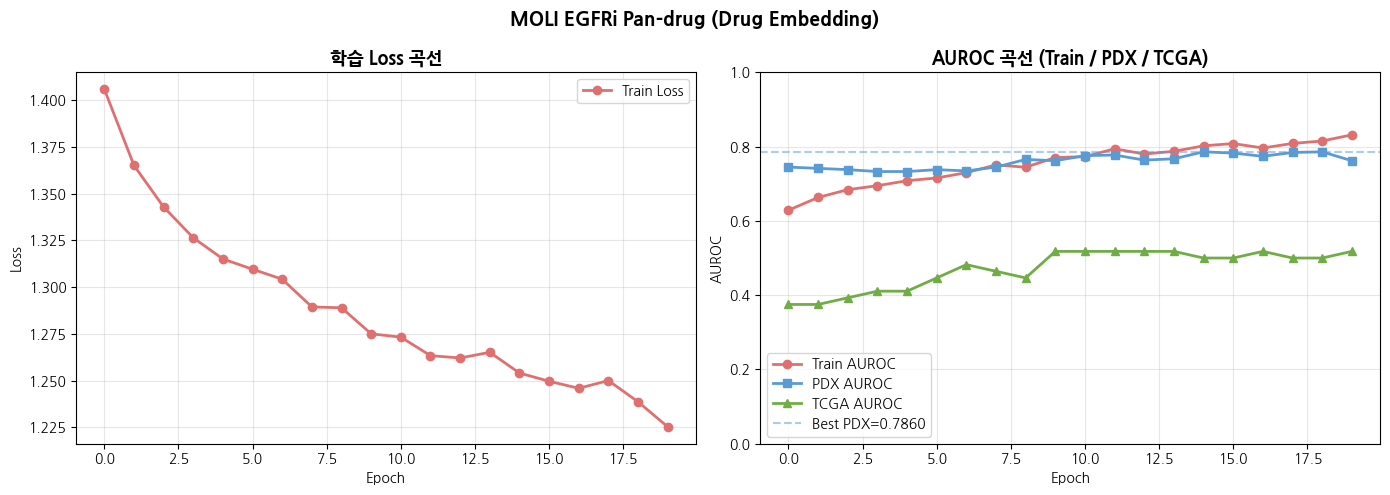

✅ 학습 곡선 저장 완료


In [25]:
# ===================================================
# 8) 학습 곡선 시각화
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], '-o', color='#E07070', label='Train Loss', linewidth=2)
axes[0].set_title('학습 Loss 곡선', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUROC
axes[1].plot(history['train_auroc'], '-o', color='#E07070', label='Train AUROC', linewidth=2)
axes[1].plot(history['pdx_auroc'],   '-s', color='#5B9BD5', label='PDX AUROC',   linewidth=2)
axes[1].plot(history['tcga_auroc'],  '-^', color='#70AD47', label='TCGA AUROC',  linewidth=2)
axes[1].axhline(y=best_pdx_auroc, color='#5B9BD5', linestyle='--', alpha=0.5,
                label=f'Best PDX={best_pdx_auroc:.4f}')
axes[1].set_title('AUROC 곡선 (Train / PDX / TCGA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('MOLI EGFRi Pan-drug (Drug Embedding)', fontsize=14, fontweight='bold')
plt.tight_layout()

output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"
plt.savefig(f'{output_dir}/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 학습 곡선 저장 완료")

In [26]:
# Best 기준: PDX AUROC + AUPR 조합 점수
def combined_score(metrics, w_auroc=0.7, w_aupr=0.3):
    """
    AUROC와 AUPR 가중 조합
    클래스 불균형 시 AUPR이 더 신뢰할 수 있음
    """
    auroc = metrics.get('AUROC', 0.0)
    aupr  = metrics.get('AUPR',  0.0)
    return w_auroc * auroc + w_aupr * aupr

In [27]:
# ===================================================
# 하이퍼파라미터 최적화 (Optuna)
# ===================================================

# 탐색 공간
# 논문 값 기준으로 ±범위 설정
SEARCH_SPACE = {
    'lr_expr'      : (1e-4, 1e-2),   # log scale
    'lr_mut'       : (1e-5, 1e-3),
    'lr_cna'       : (1e-5, 1e-3),
    'lr_cls'       : (1e-4, 1e-2),
    'weight_decay' : (1e-5, 1e-2),
    'dropout_expr' : [0.3, 0.4, 0.5, 0.6],
    'dropout_mut'  : [0.5, 0.6, 0.7, 0.8],
    'dropout_cna'  : [0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'dropout_cls'  : [0.2, 0.3, 0.4, 0.5],
    'gamma'        : (0.1, 1.0),
    'margin'       : (0.5, 3.0),
    'batch_size'   : [8, 16, 32],
    'hidden_expr'  : [16, 32, 64],
    'hidden_mut'   : [8, 16, 32],
    'hidden_cna'   : [128, 256, 512],
    'drug_emb_dim' : [4, 8, 16],
}

# 모델/옵티마이저 생성 헬퍼
def build_model_and_opts(params):
    m = MOLI(
        INPUT_DIM_EXPR, INPUT_DIM_MUT, INPUT_DIM_CNA,
        hidden_dim_expr = params.get('hidden_expr',  HIDDEN_DIM_EXPR),
        hidden_dim_mut  = params.get('hidden_mut',   HIDDEN_DIM_MUT),
        hidden_dim_cna  = params.get('hidden_cna',   HIDDEN_DIM_CNA),
        drug_emb_dim    = params.get('drug_emb_dim', DRUG_EMB_DIM),
        dropout_expr    = params['dropout_expr'],
        dropout_mut     = params['dropout_mut'],
        dropout_cna     = params['dropout_cna'],
        dropout_cls     = params['dropout_cls'],
    ).to(device)

    opts = (
        optim.Adagrad(m.expr_encoder.parameters(),   lr=params['lr_expr']),
        optim.Adagrad(m.mut_encoder.parameters(),    lr=params['lr_mut']),
        optim.Adagrad(m.cna_encoder.parameters(),    lr=params['lr_cna']),
        optim.Adagrad(m.classifier.parameters(),     lr=params['lr_cls'],
                      weight_decay=params['weight_decay']),
        optim.Adagrad(m.drug_embedding.parameters(), lr=params['lr_cls']),
    )
    return m, opts

In [28]:
def run_single_fold(params, tr_idx, val_idx, max_epochs=30, patience=5):
    """단일 fold 학습 → best score 반환"""

    # Dataset
    fold_train = OmicsDataset(
        X_train_expr_sm[tr_idx], X_train_mut_sm[tr_idx],
        X_train_cna_sm[tr_idx],  drug_id_train_sm[tr_idx],
        y_train_sm[tr_idx]
    )
    fold_val = OmicsDataset(
        X_train_expr_sm[val_idx], X_train_mut_sm[val_idx],
        X_train_cna_sm[val_idx],  drug_id_train_sm[val_idx],
        y_train_sm[val_idx]
    )

    # DataLoader
    bs = params['batch_size']
    tr_loader = DataLoader(fold_train, batch_size=bs, drop_last=True)
    va_loader = DataLoader(fold_val,   batch_size=bs, shuffle=False)

    # 모델
    m, opts = build_model_and_opts(params)
    trip_crit = nn.TripletMarginLoss(margin=params['margin'], p=2)
    bce_crit  = nn.BCELoss()
    gamma_val = params['gamma']

    best_score  = 0.0
    patience_cnt = 0

    for epoch in range(max_epochs):
        # 학습
        m.train()
        for expr, mut, cna, drug_id, target in tr_loader:
            if torch.mean(target) in [0., 1.]:
                continue
            expr, mut, cna = expr.to(device), mut.to(device), cna.to(device)
            drug_id, target = drug_id.to(device), target.to(device)

            pred, emb = m.forward_train(expr, mut, cna, drug_id)
            trips = get_hard_triplets(emb, target)
            if trips is None:
                continue

            loss = (gamma_val * trip_crit(emb[trips[:,0]],
                                           emb[trips[:,1]],
                                           emb[trips[:,2]])
                    + bce_crit(pred, target))

            for opt in opts:
                opt.zero_grad()
            loss.backward()
            for opt in opts:
                opt.step()

        # 검증
        m.eval()
        probs, trues = [], []
        with torch.no_grad():
            for expr, mut, cna, drug_id, label in va_loader:
                out = m(expr.to(device), mut.to(device),
                        cna.to(device), drug_id.to(device))
                probs.extend(out.cpu().numpy())
                trues.extend(label.numpy())

        probs = np.array(probs)
        trues = np.array(trues).astype(int)

        if len(np.unique(trues)) < 2:
            continue

        auroc = roc_auc_score(trues, probs)
        aupr  = average_precision_score(trues, probs)
        score = 0.6 * auroc + 0.4 * aupr

        if score > best_score:
            best_score   = score
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    del m
    torch.cuda.empty_cache()
    return best_score


def objective(trial):
    """Optuna objective: 3-Fold CV 평균 score 최대화"""

    params = {
        'lr_expr'      : trial.suggest_float('lr_expr',      1e-4, 1e-2,  log=True),
        'lr_mut'       : trial.suggest_float('lr_mut',       1e-5, 1e-3,  log=True),
        'lr_cna'       : trial.suggest_float('lr_cna',       1e-5, 1e-3,  log=True),
        'lr_cls'       : trial.suggest_float('lr_cls',       1e-4, 1e-2,  log=True),
        'weight_decay' : trial.suggest_float('weight_decay', 1e-5, 1e-2,  log=True),
        'dropout_expr' : trial.suggest_categorical('dropout_expr', [0.3, 0.4, 0.5, 0.6]),
        'dropout_mut'  : trial.suggest_categorical('dropout_mut',  [0.5, 0.6, 0.7, 0.8]),
        'dropout_cna'  : trial.suggest_categorical('dropout_cna',  [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]),
        'dropout_cls'  : trial.suggest_categorical('dropout_cls',  [0.2, 0.3, 0.4, 0.5]),
        'gamma'        : trial.suggest_float('gamma',   0.1, 1.0),
        'margin'       : trial.suggest_float('margin',  0.5, 3.0),
        'batch_size'   : trial.suggest_categorical('batch_size', [8, 16, 32]),
        'hidden_expr'  : trial.suggest_categorical('hidden_expr',  [16, 32, 64]),
        'hidden_mut'   : trial.suggest_categorical('hidden_mut',   [8, 16, 32]),
        'hidden_cna'   : trial.suggest_categorical('hidden_cna',   [128, 256, 512]),
        'drug_emb_dim' : trial.suggest_categorical('drug_emb_dim', [4, 8, 16]),
    }

    # 3-Fold CV
    skf    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for fold, (tr_idx, va_idx) in enumerate(
            skf.split(np.arange(len(y_train)), y_train.astype(int))):

        score = run_single_fold(
            params, tr_idx, va_idx,
            max_epochs = 25,
            patience   = 5
        )
        scores.append(score)

        # Pruning: 첫 2 fold 결과가 너무 낮으면 조기 종료
        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(scores)

In [29]:
# ===================================================
# Optuna 실행
# ===================================================
N_TRIALS = 60

study = optuna.create_study(
    direction  = 'maximize',
    study_name = 'MOLI_EGFRi_Pandrug',
    sampler    = optuna.samplers.TPESampler(seed=42),
    pruner     = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

# 논문 파라미터를 시작점으로 추가 (Trial 0)
study.enqueue_trial({
    'lr_expr'      : 0.001,
    'lr_mut'       : 0.0001,
    'lr_cna'       : 5e-5,
    'lr_cls'       : 0.005,
    'weight_decay' : 0.0001,
    'dropout_expr' : 0.5,
    'dropout_mut'  : 0.8,
    'dropout_cna'  : 0.5,
    'dropout_cls'  : 0.3,
    'gamma'        : 0.5,
    'margin'       : 1.5,
    'batch_size'   : 16,
})

print(f"🔍 Optuna 최적화 시작")
print(f"   Trials: {N_TRIALS} | Sampler: TPE | Pruner: Median")
print(f"   각 Trial = 3-Fold CV (max 25 epochs, patience 5)")
print("=" * 60)

with tqdm(total=N_TRIALS, desc="Optuna") as pbar:
    def callback(study, trial):
        pbar.update(1)
        pbar.set_postfix(
            best  = f"{study.best_value:.4f}",
            trial = trial.number,
            state = trial.state.name[:4]
        )
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[callback], gc_after_trial=True)

# 결과 출력
print("\n" + "=" * 60)
print(f"🏆 최적화 완료")
print(f"  Best score : {study.best_value:.4f}")
print(f"  Best trial : #{study.best_trial.number}")
print(f"\n  Best params:")
for k, v in study.best_params.items():
    paper = {'lr_expr':0.001,'lr_mut':0.0001,'lr_cna':5e-5,
             'lr_cls':0.005,'weight_decay':0.0001,'dropout_expr':0.5,
             'dropout_mut':0.8,'dropout_cna':0.5,'dropout_cls':0.3,
             'gamma':0.5,'margin':1.5,'batch_size':16}
    arrow = "←논문" if k in paper and abs(float(v)-float(paper[k]))<1e-9 else ""
    print(f"    {k:15s}: {v}  {arrow}")

# 파라미터 중요도
print("\n📊 파라미터 중요도:")
try:
    imp = optuna.importance.get_param_importances(study)
    for k, v in imp.items():
        bar = '█' * int(v * 25)
        print(f"  {k:15s}: {bar:<25s} {v:.3f}")
except Exception as e:
    print(f"  (중요도 계산 불가: {e})")

# study 저장
import pickle
with open(f"{save_dir}/optuna_study.pkl", 'wb') as f:
    pickle.dump(study, f)
print("\n✅ study 저장 완료 (optuna_study.pkl)")

🔍 Optuna 최적화 시작
   Trials: 60 | Sampler: TPE | Pruner: Median
   각 Trial = 3-Fold CV (max 25 epochs, patience 5)


Optuna: 100%|██████████| 60/60 [1:15:36<00:00, 75.61s/it, best=0.8121, state=PRUN, trial=59]



🏆 최적화 완료
  Best score : 0.8121
  Best trial : #19

  Best params:
    lr_expr        : 0.0018627269151350692  
    lr_mut         : 0.00017630858275387125  
    lr_cna         : 1.1066458861901494e-05  
    lr_cls         : 0.005015057758037342  
    weight_decay   : 0.0029612081613752147  
    dropout_expr   : 0.4  
    dropout_mut    : 0.7  
    dropout_cna    : 0.6  
    dropout_cls    : 0.2  
    gamma          : 0.4903349809911688  
    margin         : 2.15596049022603  
    batch_size     : 32  
    hidden_expr    : 64  
    hidden_mut     : 8  
    hidden_cna     : 128  
    drug_emb_dim   : 8  

📊 파라미터 중요도:
  batch_size     : ███████████               0.456
  lr_cls         : ████                      0.183
  hidden_expr    : ██                        0.107
  hidden_cna     : ██                        0.104
  lr_cna         :                           0.031
  dropout_cna    :                           0.021
  dropout_expr   :                           0.019
  dropout_mut    :

In [30]:
# ===================================================
# 최적 파라미터로 최종 학습
# ===================================================
best_params = study.best_params
print(f"🚀 최적 파라미터로 최종 학습")

# 전체 Train 데이터로 학습
final_model, final_opts = build_model_and_opts(best_params)
trip_crit_final = nn.TripletMarginLoss(margin=0.3, p=2)

bs_final = best_params['batch_size']
final_loader  = DataLoader(train_dataset_sm, batch_size=bs_final, drop_last=True)

best_score_final = 0.0
best_state_final = None
patience_cnt     = 0
PATIENCE_FINAL   = 10
MAX_EPOCHS_FINAL = 80

history_final = {'train_loss':[],'train_auroc':[], 'pdx_cetu':[],'pdx_erlo':[],'tcga':[]}

print("=" * 65)
for epoch in range(MAX_EPOCHS_FINAL):

    # 학습
    final_model.train()
    ep_loss, ep_auc, n_b = 0.0, [], 0
    for expr, mut, cna, drug_id, target in final_loader:
        if torch.mean(target) in [0., 1.]:
            continue
        expr, mut, cna = expr.to(device), mut.to(device), cna.to(device)
        drug_id, target = drug_id.to(device), target.to(device)
        pred, emb = final_model.forward_train(expr, mut, cna, drug_id)
        trips = get_hard_triplets(emb, target)
        if trips is None:
            continue
        loss = (best_params['gamma'] *
                trip_crit_final(emb[trips[:,0]], emb[trips[:,1]], emb[trips[:,2]])
                + bce_loss(pred, target))
        for opt in final_opts:
            opt.zero_grad()
        loss.backward()
        for opt in final_opts:
            opt.step()
        ep_loss += loss.item()
        n_b     += 1
        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            ep_auc.append(roc_auc_score(y_t, y_p))

    avg_loss  = ep_loss / max(n_b, 1)
    avg_auroc = np.mean(ep_auc) if ep_auc else 0.0

    # 검증
    pdx_res  = evaluate(final_model, val_loader,  device)
    tcga_res = evaluate(final_model, tcga_loader, device)

    pdx_cetu = pdx_res.get('Cetuximab', {}).get('AUROC', 0.0)
    pdx_erlo = pdx_res.get('Erlotinib', {}).get('AUROC', 0.0)
    pdx_auc = pdx_res.get('overall', {}).get('AUROC',  0.0)
    pdx_aupr = pdx_res.get('overall', {}).get('AUPR',  0.0)
    tcga_auc = tcga_res.get('overall', {}).get('AUROC',  0.0)

    # Best 기준: PDX AUROC×0.6 + AUPR×0.4
    score = 0.6 * pdx_auc + 0.4 * pdx_aupr
    is_best    = score > best_score_final
    if is_best:
        best_score_final = score
        best_state_final = deepcopy(final_model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1

    history_final['train_loss'].append(avg_loss)
    history_final['train_auroc'].append(avg_auroc)
    history_final['pdx_cetu'].append(pdx_cetu)
    history_final['pdx_erlo'].append(pdx_erlo)
    history_final['tcga'].append(tcga_auc)

    print(f"Epoch {epoch+1:>2} | loss={avg_loss:.4f} | "
          f"train={avg_auroc:.4f} | "
          f"PDX_Cetu={pdx_cetu:.4f} | "
          f"PDX_Erlo={pdx_erlo:.4f} | "
          f"TCGA={tcga_auc:.4f}"
          + (" ⭐" if is_best else f" [{patience_cnt}/{PATIENCE_FINAL}]"))

    if patience_cnt >= PATIENCE_FINAL:
        print(f"\n⏹ Early Stopping at epoch {epoch+1}")
        break

print("=" * 65)
final_model.load_state_dict(best_state_final)
print(f"\n🏆 Best score: {best_score_final:.4f}")
_ = evaluate(final_model, val_loader,  device, dataset_name="PDX  (최종)")
_ = evaluate(final_model, tcga_loader, device, dataset_name="TCGA (최종)")

🚀 최적 파라미터로 최종 학습
Epoch  1 | loss=0.8496 | train=0.6499 | PDX_Cetu=0.5527 | PDX_Erlo=0.5370 | TCGA=0.5893 ⭐
Epoch  2 | loss=0.7896 | train=0.7191 | PDX_Cetu=0.5782 | PDX_Erlo=0.5556 | TCGA=0.6429 ⭐
Epoch  3 | loss=0.7614 | train=0.7275 | PDX_Cetu=0.5673 | PDX_Erlo=0.6111 | TCGA=0.6250 ⭐
Epoch  4 | loss=0.7421 | train=0.7473 | PDX_Cetu=0.5527 | PDX_Erlo=0.6111 | TCGA=0.6429 ⭐
Epoch  5 | loss=0.7246 | train=0.7630 | PDX_Cetu=0.5455 | PDX_Erlo=0.6296 | TCGA=0.6429 ⭐
Epoch  6 | loss=0.7087 | train=0.7768 | PDX_Cetu=0.5418 | PDX_Erlo=0.7222 | TCGA=0.6071 ⭐
Epoch  7 | loss=0.7061 | train=0.7651 | PDX_Cetu=0.5455 | PDX_Erlo=0.7407 | TCGA=0.5714 ⭐
Epoch  8 | loss=0.6956 | train=0.7642 | PDX_Cetu=0.5418 | PDX_Erlo=0.7407 | TCGA=0.5536 ⭐
Epoch  9 | loss=0.6824 | train=0.7833 | PDX_Cetu=0.5345 | PDX_Erlo=0.7778 | TCGA=0.5714 ⭐
Epoch 10 | loss=0.6787 | train=0.7783 | PDX_Cetu=0.5309 | PDX_Erlo=0.7963 | TCGA=0.5893 ⭐
Epoch 11 | loss=0.6649 | train=0.7939 | PDX_Cetu=0.5273 | PDX_Erlo=0.7963 | TCGA=0.

In [31]:
# ===================================================
# 학습 함수 정의_학습 기준 변경
# ===================================================

def train_one_epoch(model, loader, optimizers, device):
    """한 epoch 학습 → (avg_loss, avg_auroc) 반환"""
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    solverE, solverM, solverC, solverCLS, solverDRUG = optimizers

    for expr, mut, cna, drug_id, target in loader:

        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        triplets = get_hard_triplets(embeddings, target)
        if triplets is None:
            continue

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],
            embeddings[triplets[:, 1]],
            embeddings[triplets[:, 2]]
        )
        bce  = bce_loss(pred, target)
        loss = GAMMA * trip_loss + bce

        for opt in optimizers:
            opt.zero_grad()
        loss.backward()
        for opt in optimizers:
            opt.step()

        epoch_loss += loss.item()
        n_batches  += 1

        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0
    return avg_loss, avg_auroc

print("✅ 학습 함수 준비 완료")

✅ 학습 함수 준비 완료


In [33]:
# ===================================================
# 5-Fold CV + Early Stopping
# ===================================================

best_params = study.best_params

def run_cv(params, n_splits=5, max_epochs=50, patience=7, verbose=True):

    # Trip/BCE loss는 파라미터에 따라 새로 생성
    trip_crit = nn.TripletMarginLoss(margin=best_params['margin'], p=2)
    bce_crit  = nn.BCELoss()

    # 전체 Train 데이터 인덱스
    indices = np.arange(len(y_train))
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    best_state_fold = []
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(indices, y_train.astype(int))):

        if verbose:
            print(f"\n  📂 Fold {fold+1}/{n_splits}")

        # Fold별 데이터셋

        fold_train = OmicsDataset(
            X_train_expr_sm[tr_idx],  X_train_mut_sm[tr_idx],
            X_train_cna_sm[tr_idx],   drug_id_train_sm[tr_idx],
            y_train_sm[tr_idx]
        )
        fold_val = OmicsDataset(
            X_train_expr_sm[val_idx], X_train_mut_sm[val_idx],
            X_train_cna_sm[val_idx],  drug_id_train_sm[val_idx],
            y_train_sm[val_idx]
        )

        # DataLoader
        bs = best_params['batch_size']
        fold_train_loader = DataLoader(fold_train, batch_size=bs, drop_last=True)
        fold_val_loader = DataLoader(fold_val,   batch_size=bs, shuffle=False)

        # 모델 + Optimizer
        model_cv, optimizers_cv = build_model_and_opts(best_params)

        # Early Stopping 변수
        best_score    = 0.0
        best_state    = None
        patience_cnt  = 0

        for epoch in range(max_epochs):

            # 1) 학습
            avg_loss, avg_auroc = train_one_epoch(
                model_cv, fold_train_loader, optimizers_cv, device
            )

            # 2) 검증 (Fold Val = Train 일부)
            fold_val_results = evaluate(model_cv, fold_val_loader, device)
            fold_metrics     = fold_val_results.get('overall', {})
            score            = fold_metrics.get('AUROC', 0.0)

            # 3) Best 기준: AUROC + AUPR 조합 점수
            if score > best_score:
                best_score = score
                best_state = deepcopy(model_cv.state_dict())
                patience_cnt = 0
            else:
                patience_cnt += 1

            if verbose:
                auroc = fold_metrics.get('AUROC', 0.0)
                aupr  = fold_metrics.get('AUPR',  0.0)
                mark  = " ⭐" if patience_cnt == 0 else ""
                print(f"    Epoch {epoch+1:>2} | loss={avg_loss:.4f} | "
                      f"AUROC={auroc:.4f} AUPR={aupr:.4f} "
                      f"score={score:.4f}{mark} "
                      f"[patience {patience_cnt}/{patience}]")

            # 4) Early Stopping
            if patience_cnt >= patience:
                if verbose:
                    print(f"    ⏹ Early Stopping at epoch {epoch+1}")
                break

        best_state_fold.append(best_state)
        fold_scores.append(best_score)
        if verbose:
            print(f"  ✅ Fold {fold+1} Best score: {best_score:.4f}")

    return best_state_fold, fold_scores


# 5-fold CV 시작

print("🔁 5-Fold CV 시작")
print(f"   Early Stopping patience=7 | max_epochs=50")
print(f"   Best 기준: AUROC×0.6 + AUPR×0.4")
print("=" * 60)

best_state, cv_scores = run_cv(best_params, n_splits=5, max_epochs=50, patience=7)

print("\n" + "=" * 60)
print(f"📊 5-Fold CV 결과:")
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"  평균: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

🔁 5-Fold CV 시작
   Early Stopping patience=7 | max_epochs=50
   Best 기준: AUROC×0.6 + AUPR×0.4

  📂 Fold 1/5
    Epoch  1 | loss=1.4504 | AUROC=0.8240 AUPR=0.6299 score=0.8240 ⭐ [patience 0/7]
    Epoch  2 | loss=1.4043 | AUROC=0.8490 AUPR=0.6731 score=0.8490 ⭐ [patience 0/7]
    Epoch  3 | loss=1.3763 | AUROC=0.8598 AUPR=0.6941 score=0.8598 ⭐ [patience 0/7]
    Epoch  4 | loss=1.3605 | AUROC=0.8674 AUPR=0.7043 score=0.8674 ⭐ [patience 0/7]
    Epoch  5 | loss=1.3459 | AUROC=0.8733 AUPR=0.7145 score=0.8733 ⭐ [patience 0/7]
    Epoch  6 | loss=1.3312 | AUROC=0.8779 AUPR=0.7179 score=0.8779 ⭐ [patience 0/7]
    Epoch  7 | loss=1.3241 | AUROC=0.8817 AUPR=0.7193 score=0.8817 ⭐ [patience 0/7]
    Epoch  8 | loss=1.3228 | AUROC=0.8836 AUPR=0.7241 score=0.8836 ⭐ [patience 0/7]
    Epoch  9 | loss=1.3047 | AUROC=0.8865 AUPR=0.7269 score=0.8865 ⭐ [patience 0/7]
    Epoch 10 | loss=1.2956 | AUROC=0.8877 AUPR=0.7263 score=0.8877 ⭐ [patience 0/7]
    Epoch 11 | loss=1.2925 | AUROC=0.8897 AUPR=0.7267

In [34]:
print("=" * 60)
aurocs = []

for i, state in enumerate(best_state):
    model_cv, _ = build_model_and_opts(best_params)
    model_cv.load_state_dict(state)
    model_cv.to(device)

    print("\n✅ Best 모델 로드 완료 → 최종 평가")
    res = evaluate(model_cv, val_loader, device, dataset_name="PDX (Best)")

    auroc = res.get("overall", {}).get("AUROC", 0.0)
    aurocs.append(auroc)
    print(f"Fold {i+1} PDX AUROC: {auroc:.4f}")

print(f"\n[최종 결과] 평균 PDX AUROC: {np.mean(aurocs):.4f}")


✅ Best 모델 로드 완료 → 최종 평가

📊 PDX (Best) 평가 결과
  [전체]
    AUROC     : 0.6712
    AUPR      : 0.2677
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.5455
    AUPR      : 0.1879
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.8333
    AUPR      : 0.4889
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
Fold 1 PDX AUROC: 0.6712

✅ Best 모델 로드 완료 → 최종 평가

📊 PDX (Best) 평가 결과
  [전체]
    AUROC     : 0.6147
    AUPR      : 0.2290
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.5418
    AUPR      : 0.2003
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.7407
    AUPR      : 0.4048
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
  

In [35]:
print("=" * 60)
aurocs = []

for i, state in enumerate(best_state):
    model_cv, _ = build_model_and_opts(best_params)
    model_cv.load_state_dict(state)
    model_cv.to(device)

    print("\n✅ Best 모델 로드 완료 → 최종 평가")
    res = evaluate(model_cv, tcga_loader, device, dataset_name="TCGA (Best)")

    auroc = res.get("overall", {}).get("AUROC", 0.0)
    aurocs.append(auroc)
    print(f"Fold {i+1} TCGA AUROC: {auroc:.4f}")

print(f"\n[최종 결과] 평균 TCGA AUROC: {np.mean(aurocs):.4f}")


✅ Best 모델 로드 완료 → 최종 평가

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5714
    AUPR      : 0.5206
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.2917
    AUPR      : 0.5267
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.0000
    AUPR      : 0.3333
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
Fold 1 TCGA AUROC: 0.5714

✅ Best 모델 로드 완료 → 최종 평가

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5000
    AUPR      : 0.4859
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.2083
    AUPR      : 0.4981
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.0000
    AUPR      : 0.3333
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000